# Run scVI on gastrulation multiome RNA

In [1]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 and will be removed in v1.9. Please use `pytorch_lightning.loggers.logger.rank_zero_experiment` instead.
  return new_rank_zero_deprecation(*args, **kwargs)


In [2]:
basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/epiblast_blood/'

In [3]:
adata = sc.read_h5ad(basedir + 'anndata.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 12686 × 20519
    obs: 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'doublet_score', 'celltype', 'celltype.score', 'closest.cell'
    var: 'name'

In [5]:
# preprocessing
sc.pp.filter_genes(adata, min_counts=3)
adata.layers["counts"] = adata.X.copy() # preserve counts
adata.raw = adata # freeze the state in `.raw`

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    subset=True,
    layer="counts",
    flavor="cell_ranger",
    batch_key="stage"
)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variabl

# Train model

In [6]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="stage",
    categorical_covariate_keys=["sample"]
)

INFO     Using batches from adata.obs["stage"]                                               
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 12686 cells, 2500 vars, 5 batches,
         1 labels, and 0 proteins. Also registered 1 extra categorical covariates and 0 extra
         continuous covariates.                                                              
INFO     Please do not further modify adata until model is trained.                          


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [7]:
model = scvi.model.SCVI(adata, n_latent=25)

In [8]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 400/400: 100%|██████████| 400/400 [44:37<00:00,  6.69s/it, loss=772, v_num=1]


In [9]:
model.save(basedir + 'scvi_model/')

# Inspect model

In [10]:
model = scvi.model.SCVI.load(basedir + 'scvi_model/', adata)

INFO     Using data from adata.layers["counts"]                                              
INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 12686 cells, 2500 vars, 5 batches,
         1 labels, and 0 proteins. Also registered 1 extra categorical covariates and 0 extra
         continuous covariates.                                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [11]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)

In [12]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

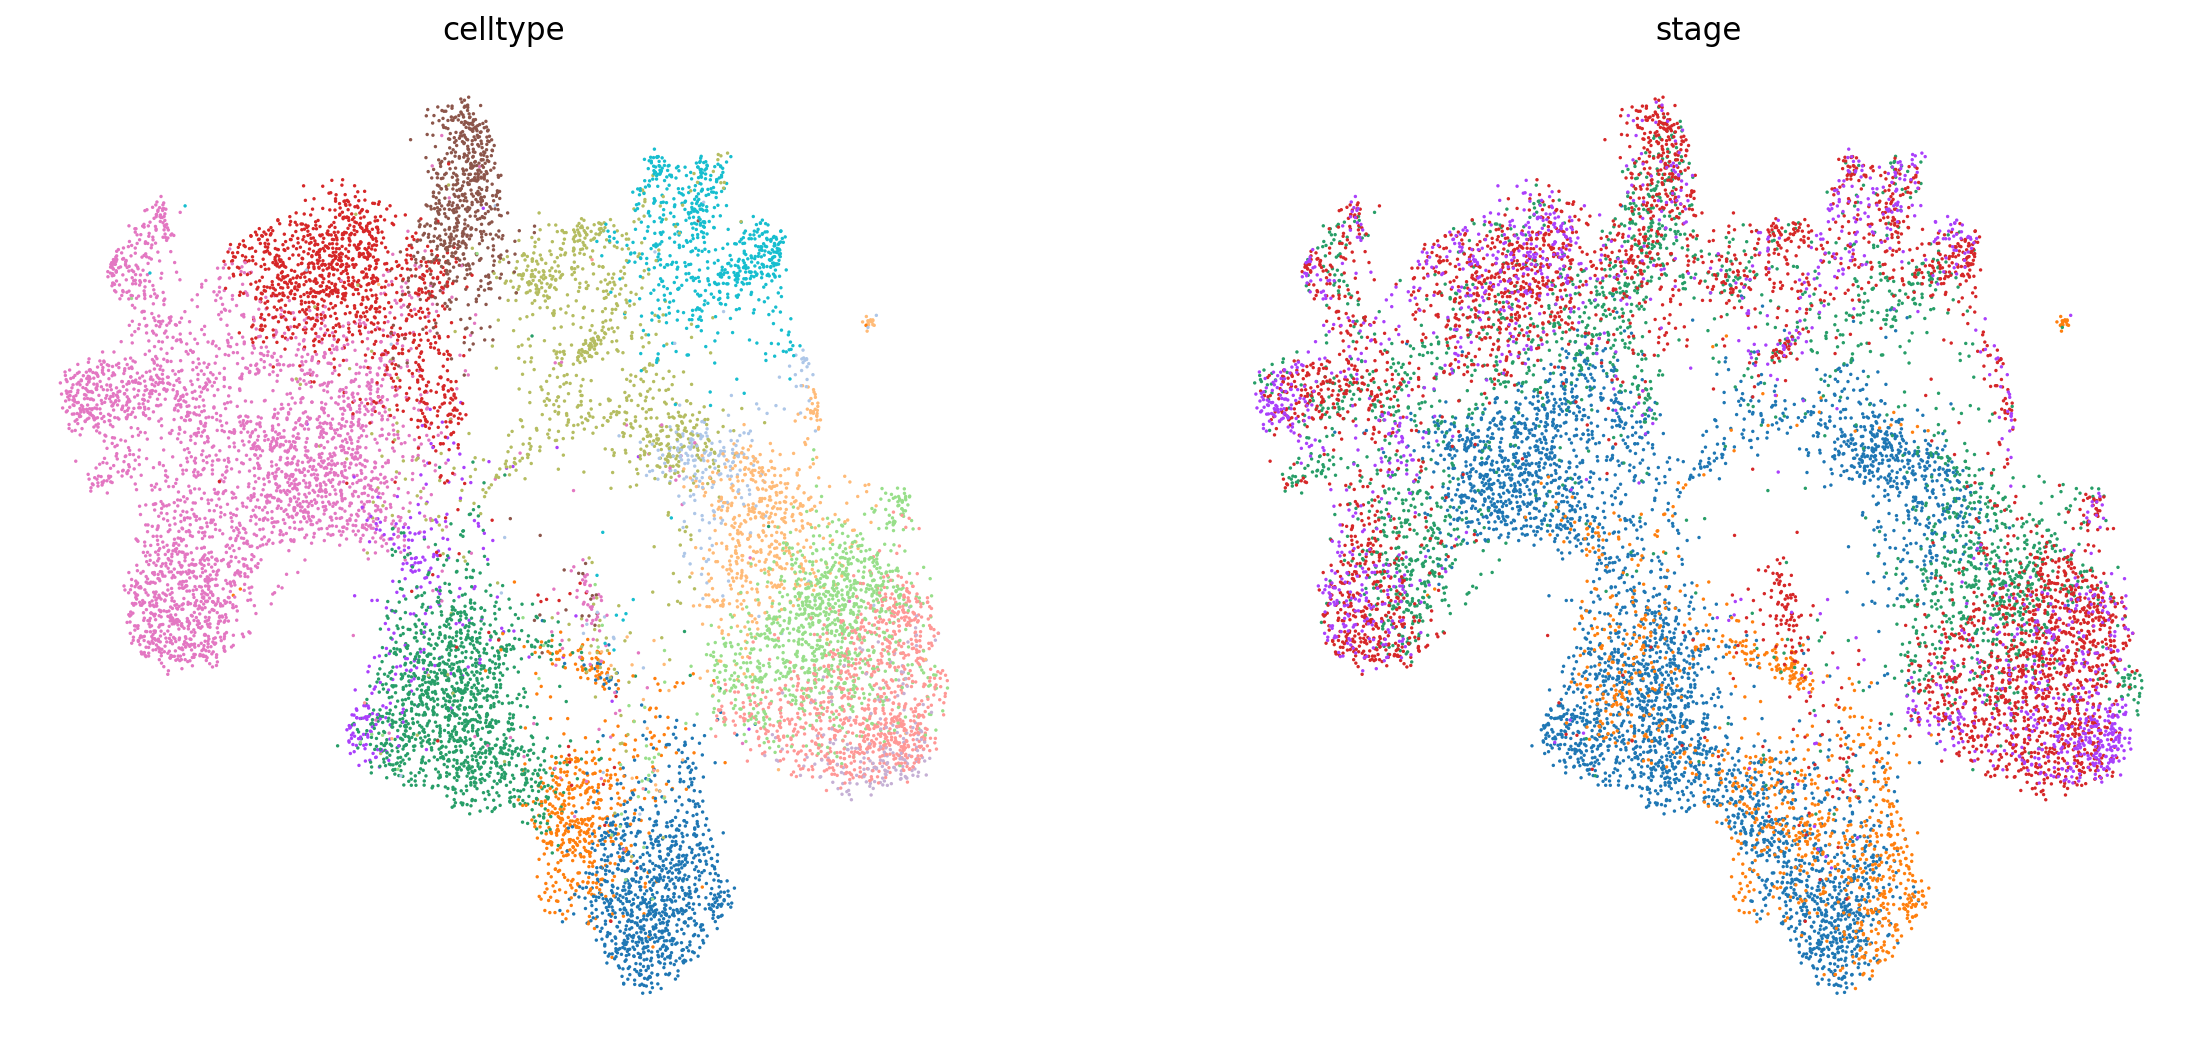

In [15]:
sc.pl.umap(
    adata,
    color=["celltype", "stage"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [16]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv(basedir + 'scVI_umap.csv')
latent.to_csv(basedir + 'scVI_latent.csv')

# Train model - switch batch & covariate key

In [6]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="sample",
    categorical_covariate_keys=["stage"]
)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scvi/data/_utils.py:114: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [7]:
model = scvi.model.SCVI(adata, n_latent=25)

In [9]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 400/400: 100%|██████████| 400/400 [53:34<00:00,  8.12s/it, loss=785, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [53:34<00:00,  8.04s/it, loss=785, v_num=1]


In [10]:
model.save(basedir + 'scvi_model2/')

# Inspect model

In [11]:
model = scvi.model.SCVI.load(basedir + 'scvi_model2/', adata)

INFO     File                                                                                                      
         /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/epiblast_blood/scvi_model2
         /model.pt already downloaded                                                                              


/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scvi/data/_utils.py:114: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [12]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)

In [13]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

Epoch 5/400:   1%|          | 4/400 [55:29<91:34:17, 832.47s/it, loss=838, v_num=1]


/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


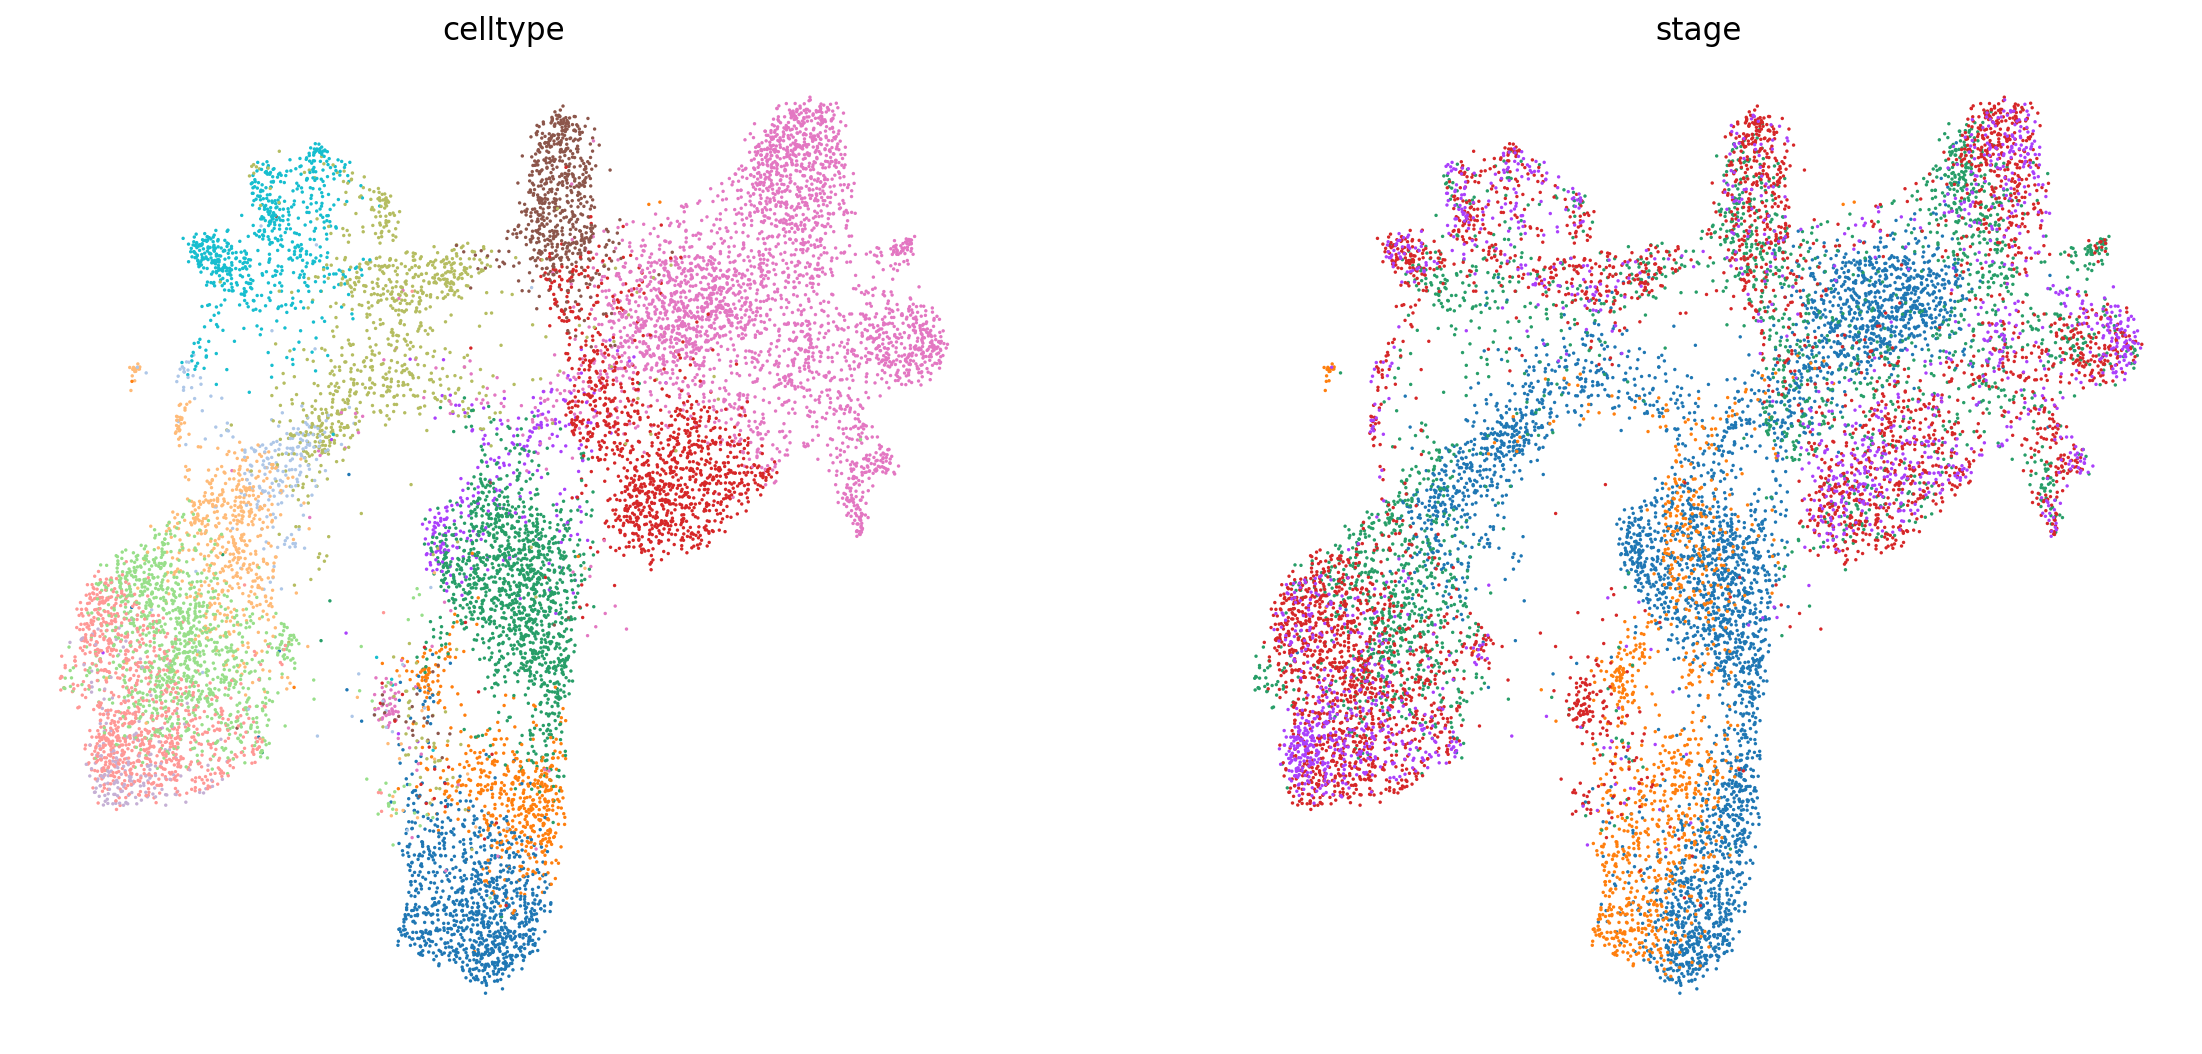

In [14]:
sc.pl.umap(
    adata,
    color=["celltype", "stage"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [15]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv(basedir + 'scVI_umap2.csv')
latent.to_csv(basedir + 'scVI_latent2.csv')